# Q2: Are Zurichs Ice Hockey Fans responsible for graffitis?
Zurichs ice hockey Team ZSC Lions moved from the Hallenstadion in Oerlikon to the Swiss Life Arena in Altstetten back in 2022 (https://www.swisslifearena.ch/arena/geschichte/). This question focuses on determining wheter the number of reported graffitis has decreased in Oerlikon and increased in Altstetten after the local ice hockey team changed its home stadium in 2022. The idea is to derive the number of reported graffitis for both locations at two different time periods, one before and one after the the moving.

**Summarized workflow:**  

0. Import all packages needed
1. Import the files needed
2. Filter for the two neighborhoods needed
3. Filter for the category graffiti
4. Filter for the two timespanns needed 
5. Export the results as a table 
6. Plot the results and export them

## 0. Importing all packages

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import cmcrameri.cm as cmc
from pathlib import Path
import xarray as xr
#from matplotlib_scalebar.scalebar import ScaleBar

import sys
sys.path.append("../scripts")

from functions_zh_wie_neu import import_preprocessed_data #type: ignore
from functions_zh_wie_neu import export_result_to_png #type: ignore

## 1. Import the data needed

In [2]:
quartiere=import_preprocessed_data("quartiere_processed.gpkg")
reports_complete=import_preprocessed_data("reports_quartiere_sjoin.gpkg")

The active geometry column of this geodataframe is called 'geometry'.
The active geometry column of this geodataframe is called 'geometry'.


## 2. Filter for the two neighborhoods needed
First, we need to determine which two neighborhoods are actually needed. Apparently, the names of the two statistical neighborhoods are Altstetten and Oerlikon (visually derived from: https://www.stadt-zuerich.ch/geodaten/download/Statistische_Quartiere?format=10005). 

In [3]:
# Filter the reports for these two neighborhoods:
reports_hockey=reports_complete[(reports_complete["qname"]=="Altstetten") | (reports_complete["qname"]=="Oerlikon")]

#check for the unique quartier names:
print(reports_hockey["qname"].unique()) #only Altstetten and Oerlikon present

<ArrowStringArray>
['Altstetten', 'Oerlikon']
Length: 2, dtype: str


In [4]:
#make a function out of this!!!
n_reports=(
    reports_complete
    .groupby("qname")
    .size()
    .reset_index(name="nr_reports")#this transforms the qnr to a data column named nr_reports (after the code above it was set as the index)
    .sort_values(by="nr_reports",ascending=False) #displays me the highest values first
)

n_reports_hockey=n_reports[(n_reports["qname"]=="Altstetten") | (n_reports["qname"]=="Oerlikon")]
n_reports_hockey.head(2)

#second check: how many rows are present:
if  reports_hockey.shape[0]==n_reports_hockey["nr_reports"].sum():
    print("Correct.")

Correct.


* Put the reports per neighborhood into a function and import it
* sturcture it nicely

## 3. Filter for the category graffiti
* add notes and describe code!!!

In [5]:
reports_hockey=reports_hockey[reports_hockey["service_code"]=="Graffiti"]
reports_hockey.shape

(293, 12)

## 4. Filter for the two timeframes
The two time-intervalls are filtered into two different geodataframes, called reports_before_moving and reports_after_moving. The two time-intervalls were selected to span the same time (43 months), and start and end data within the year were selected to be similar, to avoid a potential bias of less expected reports during the "summer break". Therfore, the two selected time-intervalls were:
| geodataframe | time-intervall |
|---|---|
| reports_before_moving | 18.10.2015-18.05.2019 |
 |reports_after_moving | 18.10.2022-18.05.2026 |

In [6]:
#filter all reports for the first time-intervall
reports_before_moving=reports_hockey[reports_hockey["requested_datetime"].between("18.10.2015", "18.05.2019")]
print(reports_before_moving.shape)

reports_after_moving=reports_hockey[reports_hockey["requested_datetime"].between("18.10.2022", "18.05.2026")]
print(reports_after_moving.shape)

(81, 12)
(127, 12)


## 5. Create a Table to export
The first result should be obtained by creating a table showing how many graffiti reports were issued per time-intervall in both neighborhoods.

In [7]:
#before moving
number_of_reports_before=(
        reports_before_moving
        .groupby("qname")
        .size()
        .reset_index(name="nr_reports_b")#this transforms the qnr to a data column named nr_reports (after the code above it was set as the index)
        .sort_values(by="nr_reports_b",ascending=False) #displays me the highest values first
    )
display(number_of_reports_before)

number_of_reports_after=(
        reports_after_moving
        .groupby("qname")
        .size()
        .reset_index(name="nr_reports_a")#this transforms the qnr to a data column named nr_reports (after the code above it was set as the index)
        .sort_values(by="nr_reports_a",ascending=False) #displays me the highest values first
    )

display(number_of_reports_after)

number_of_reports_time=number_of_reports_before.merge(
    number_of_reports_after, 
    on="qname",
    how="inner"
)
display(number_of_reports_time.head(2))

,qname,nr_reports_b
0,Altstetten,60
1,Oerlikon,21


,qname,nr_reports_a
0,Altstetten,75
1,Oerlikon,52


,qname,nr_reports_b,nr_reports_a
0,Altstetten,60,75
1,Oerlikon,21,52


From this result, I want to create a table to export and then use in the project report

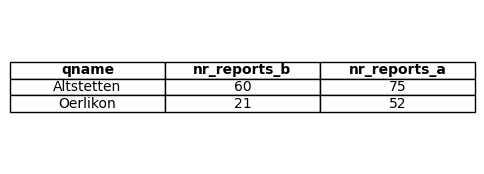

<Figure size 640x480 with 0 Axes>

In [ ]:
fig, ax = plt.subplots(figsize=(6,2))

ax.axis("off")

table=ax.table(
    cellText=number_of_reports_time.values,
    colLabels=number_of_reports_time.columns,
    loc="center",
    cellLoc="center",
    colLoc="center")

#trying to get bold column names:
for (row,col), cell in table.get_celld().items(): #celld is for cell_dictionary consiting of the location (row, col) and for what is written inside the cell. .items(gives us both of it)
    if row==0:
        cell.set_text_props(weight="bold") #props is for propoerties

export_result_to_png("Q2_final_table")
plt.show()
plt.clf()

# IF TIME:
* color this table slighly, 
* change the names of the columns (in the script above)
* implement more functions


## 6. Create a nice map of the results
This step I can do after my small break